# Driver gene identification using DE(Differential Expression) method.

In [3]:
import cafe

## Load dataset

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cafe', 'filename'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

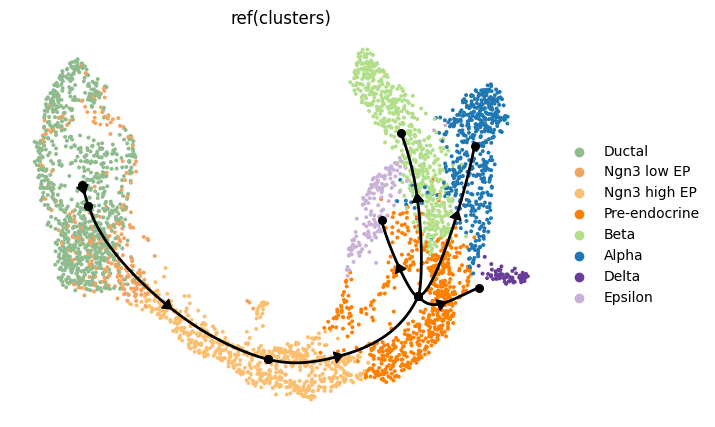

In [5]:
fadata = cafe.data.read_pancreas()
cafe.plot.plot_trajectory(fadata)
fadata

## Preprocess

In [9]:
import scanpy as sc

sc.pp.normalize_total(fadata)
sc.pp.log1p(fadata)
sc.pp.highly_variable_genes(fadata, n_top_genes=2000,)
fadata = fadata[:, fadata.var["highly_variable"]]
fadata

AnnData object with n_obs × n_vars = 3696 × 2000
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
    var: 'highly_variable_genes', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cafe', 'filename', 'log1p', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

## Extract lineages and compute driver gene

In [20]:
# extract lineages
driver = cafe.downstream.DriverGene(fadata, model_name="ref")
driver.compute_lineages() # extract the lineage corresponding to the leaf nodes of the tree milestone network

# compute driver gene
fadata.layers["lognorm"] = fadata.X.copy() # DE methods require a layer to be specified
de_result = driver.compute(
    method="de",
    # lineages=["Alpha", "Beta"],
    test="wilcoxon",
    layer="lognorm",
    min_cells=20,
)

# extract top driver gene
top_driver_genes = (
    de_result.table
    .sort_values(["lineage", "score"], ascending=[True, False])
    .groupby("lineage", group_keys=False)
    .head(5)
    [["lineage", "gene", "score", "logfoldchange", "pval", "qval"]]
)
top_driver_genes

,lineage,gene,score,logfoldchange,pval,qval
0,Alpha,Tmem27,18.807573,1.888857,6.546769e-79,1.309354e-75
1,Alpha,Ttr,15.920214,1.333965,4.588059e-57,3.058706e-54
2,Alpha,Smarca1,15.756180,1.956677,6.228559e-56,3.114280e-53
3,Alpha,Gcg,15.182925,5.356993,4.588532e-52,1.529511e-49
4,Alpha,Gpx3,14.013013,1.247349,1.297803e-44,3.708010e-42
2000,Beta,Gng12,24.893124,2.692551,8.831942e-137,1.766388e-133
2001,Beta,Pdx1,23.430674,2.312300,2.081167e-121,2.081167e-118
2002,Beta,Nnat,22.715605,4.465755,3.141073e-114,2.094049e-111
2003,Beta,Hadh,20.861452,2.007600,1.199737e-96,5.998686e-94
2004,Beta,Dlk1,20.816263,1.977556,3.083099e-96,1.233240e-93


## Visulize driver gene

array([[<Axes: title={'center': 'ref(Tmem27)'}, xlabel='_milestone_network_emb1', ylabel='_milestone_network_emb2'>,
        <Axes: title={'center': 'ref(Tmem27)'}, xlabel='_milestone_network_emb1', ylabel='_milestone_network_emb2'>,
        <Axes: title={'center': 'ref(Tmem27)'}, xlabel='_milestone_network_emb1', ylabel='_milestone_network_emb2'>,
        <Axes: title={'center': 'ref(Tmem27)'}, xlabel='_milestone_network_emb1', ylabel='_milestone_network_emb2'>]],
      dtype=object)

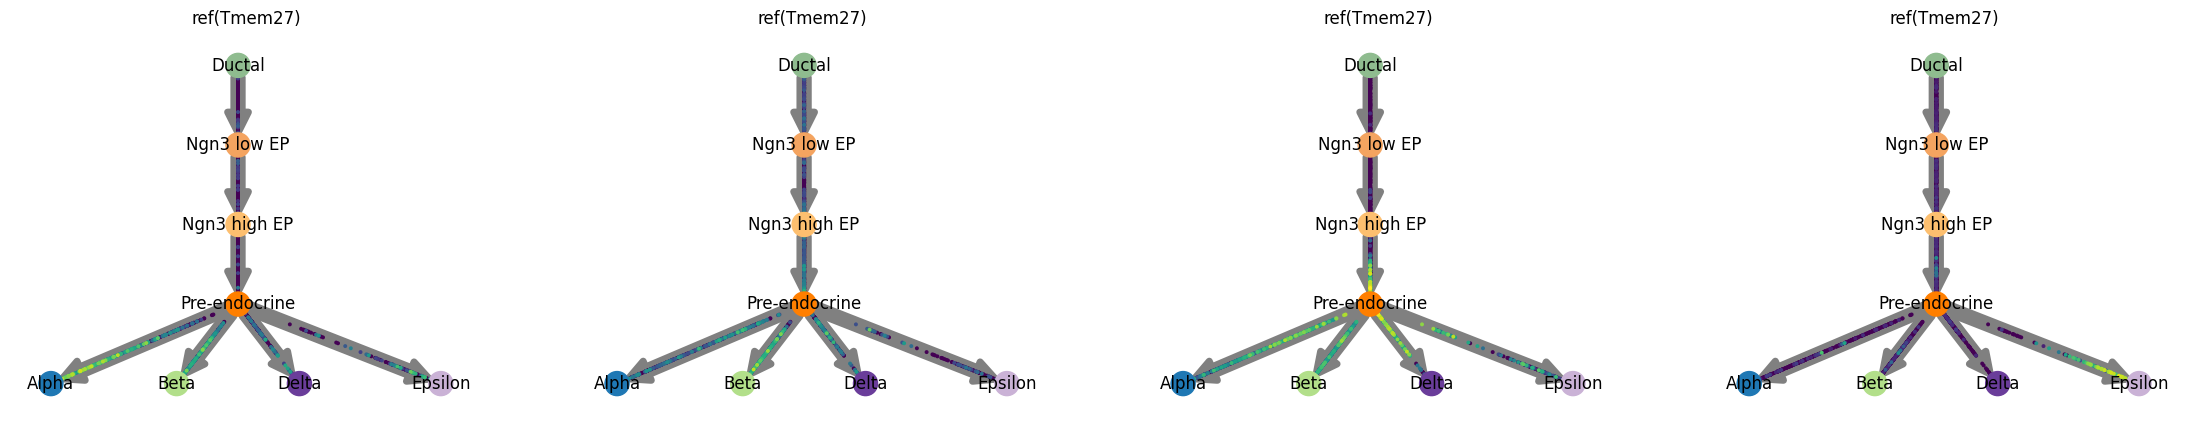

In [33]:
top_driver_gene_list = top_driver_genes.groupby("lineage").first()["gene"].tolist() # extract the top driver gene for each lineage
cafe.plot.plot_graph(fadata, color= top_driver_gene_list, colorbar_loc=None)

## Next: The DE is the baseline method for driver gene identification. More accurate algorithm should be added to the cafe framework